In [152]:
# I didn't measure launch success so I will use (as close as I can)
# to the industry standard of 50% visibility score, 40% race performance,
# and 10% for special events (playoffs etc)

# since colinearity for finish position and laps led is incredibly high 
# I will just be using laps led, because it had stronger correlation with visibility 

# Define weight configuration
WEIGHT_CONFIG = {
    'category_weights': {
        'laps_led': 0.40,    # 40% of total score
        'visibility_score': 0.50,      # 50% of total score
        'special_events': 0.10       # 10% of total score
    },
    'variable_weights_within_category': {
        'laps_led': {
            'laps_led': 1.00
        },
        'special_events': {
            'is_win': 0.60,           # 60% of special events weight
            'is_playoff': 0.40        # 40% of special events weight
        },
        'visibility_score': {
            'visibility_score': 1.00
    }
}
}
# Calculate effective weights for each variable
def calculate_effective_weights(config):
    """
    Calculate the final weight for each variable.

    Parameters:
    -----------
    config : dict
        Weight configuration with category and variable weights

    Returns:
    --------
    dict : Effective weight for each variable
    """
    effective = {}
    for category, cat_weight in config['category_weights'].items():
        var_weights = config['variable_weights_within_category'].get(category, {})
        for var, var_weight in var_weights.items():
            effective[var] = cat_weight * var_weight
    return effective

effective_weights = calculate_effective_weights(WEIGHT_CONFIG)

print("Effective Variable Weights:")
print("="*50)
for var, weight in sorted(effective_weights.items(), key=lambda x: -x[1]):
    print(f"{var:<30}: {weight*100:>5.1f}%")
print(f"{'TOTAL':<30}: {sum(effective_weights.values())*100:>5.1f}%")

Effective Variable Weights:
visibility_score              :  50.0%
laps_led                      :  40.0%
is_win                        :   6.0%
is_playoff                    :   4.0%
TOTAL                         : 100.0%


In [153]:
weight_rationale = """
# Visibility Score: Weighting Rationale

## Overall Philosophy

The weighting scheme prioritizes **on-track performance and media exposure** because:

1. On-track results determine visibility opportunity (better finishes = more camera time)
2. Traditional media still reaches the largest audience for NASCAR content
3. Social engagement, while valuable, represents a subset of total audience

## Category Rationale

### Race Performance (40%)

*Why 40%?* Race performance is the foundation of sponsorship value. A sponsor on a winning car gets exponentially more exposure than one on a mid-pack car. Our EDA showed that finish position correlates strongly with all visibility metrics.

**Variable breakdown:**
- **Laps Led (100%)**: Laps led is a strong proxy for race dominance
### Visibility Score (50%)
*Why 50%?* Visibility score is a composite metric that captures the total exposure across all media channels. It is the most direct measure of how much attention a driver and their sponsors receive.
**Variable breakdown:**
- **Visibility Score (100%)**: This is the aggregated score from all visibility sources,
### Special Events (10%)

*Why 10%?* Wins and playoff races generate disproportionate visibility spikes that should be captured.

**Variable breakdown:**
- **Wins (60%)**: A win generates 3-5x normal visibility. Even a small bonus weight has large impact when activated.
- **Playoffs (40%)**: Playoff races have higher stakes and more viewers. Built-in visibility multiplier.

## Design Decisions

### Why not equal weights?

Equal weights (14.3% each for 7 variables) would:
- Treat Reddit mentions as equally important as race wins
- Ignore the hierarchical importance of performance vs. social

### Why not data-driven weights from regression?

Regression-based weights would:
- Require a labeled "visibility outcome" variable (which doesn't exist)
- Be sensitive to sample size and outliers
- Be harder to explain to stakeholders

The hybrid approach provides transparency and defensibility.

## Sensitivity Testing

We will test alternative weight configurations in Substep 4.3.3:
- Higher performance weight (50/25/15/10)
- Higher media weight (30/40/20/10)
- Equal weights (25/25/25/25)

If rankings change significantly under alternative weights, we'll note the sensitivity in our methodology.
"""

# Save rationale document
with open('weighting_rationale.md', 'w') as f:
    f.write(weight_rationale)

print("Weighting rationale saved to: weighting_rationale.md")

Weighting rationale saved to: weighting_rationale.md


In [154]:
import json

# Full configuration for scoring model
SCORING_CONFIG = {
    'version': '1.0',
    'created_date': '2026-07-10',  # Update with actual date
    'category_weights': {
        'race_performance': 0.40,
        'visibility_score': 0.50,
        'special_events': 0.10
    },
    'variables': {
        'finish_position': {
            'category': 'race_performance',
            'weight_within_category': 0,
            'effective_weight': 0,
            'direction': 'inverse',
            'transform': 'invert_position'
        },
        'laps_led': {
            'category': 'race_performance',
            'weight_within_category': 1,
            'effective_weight': 0.4,
            'direction': 'direct',
            'transform': 'normalize'
        },
        'news_weighted_mentions': {
            'category': 'visibility_score',
            'weight_within_category': 'N/A',  # Placeholder for actual weight
            'effective_weight': 'N/A',  # Placeholder for actual effective weight
            'direction': 'direct',
            'transform': 'normalize'
        },
        'reddit_mentions': {
            'category': 'visibility_score',
            'weight_within_category': 'N/A',  # Placeholder for actual weight
            'effective_weight': 'N/A',  # Placeholder for actual effective weight
            'direction': 'direct',
            'transform': 'normalize'
        },
        'youtube_sponsor_views': {
            'category': 'visibility_score',
            'weight_within_category': 'N/A',  # Placeholder for actual weight
            'effective_weight': 'N/A',  # Placeholder for actual effective weight
            'direction': 'direct',
            'transform': 'normalize'
        },
        'is_win': {
            'category': 'special_events',
            'weight_within_category': 0.60,
            'effective_weight': 0.06,
            'direction': 'direct',
            'transform': 'binary'
        },
        'is_playoff': {
            'category': 'special_events',
            'weight_within_category': 0.40,
            'effective_weight': 0.04,
            'direction': 'direct',
            'transform': 'binary'
        }
    }
}

# Save configuration
with open('scoring_config.json', 'w') as f:
    json.dump(SCORING_CONFIG, f, indent=2)

print("Scoring configuration saved to: scoring_config.json")

Scoring configuration saved to: scoring_config.json


In [155]:
import pandas as pd

def normalize_to_100(series, direction='direct'):
    """
    Normalize a series to 0-100 scale.

    Parameters:
    -----------
    series : pd.Series
        Values to normalize
    direction : str
        'direct' if higher is better, 'inverse' if lower is better

    Returns:
    --------
    pd.Series : Normalized values (0-100 scale)
    """
    min_val = series.min()
    max_val = series.max()

    if max_val == min_val:
        # Avoid division by zero
        return pd.Series([50] * len(series), index=series.index)

    if direction == 'direct':
        # Higher original = higher normalized (0 at min, 100 at max)
        normalized = (series - min_val) / (max_val - min_val) * 100
    elif direction == 'inverse':
        # Lower original = higher normalized (100 at min, 0 at max)
        normalized = (max_val - series) / (max_val - min_val) * 100
    else:
        raise ValueError(f"Direction must be 'direct' or 'inverse', got {direction}")

    return normalized

# Test on sample data
sample = pd.Series([1, 5, 10, 20, 40])  # Finish positions

print("Sample Finish Positions:", sample.tolist())
print("Normalized (inverse):", normalize_to_100(sample, 'inverse').round(1).tolist())

Sample Finish Positions: [1, 5, 10, 20, 40]
Normalized (inverse): [100.0, 89.7, 76.9, 51.3, 0.0]


In [156]:
def prepare_binary(series):
    """
    Convert binary variable to 0-100 scale.

    Parameters:
    -----------
    series : pd.Series
        Binary values (0 or 1)

    Returns:
    --------
    pd.Series : Scaled to 0-100 (0 stays 0, 1 becomes 100)
    """
    return series * 100

# Test
wins = pd.Series([0, 0, 1, 0, 0])
print("\\nWin Flag Scoring:")
print(pd.DataFrame({'is_win': wins, 'score': prepare_binary(wins)}))

\nWin Flag Scoring:
   is_win  score
0       0      0
1       0      0
2       1    100
3       0      0
4       0      0


In [157]:
AGGREGATION_METHODS = {
    'season_total': {
        'method': 'sum',
        'description': 'Sum of all weekly visibility scores',
        'use_case': 'Total season exposure'
    },
    'season_average': {
        'method': 'mean',
        'description': 'Average weekly visibility score',
        'use_case': 'Consistency measurement'
    },
    'best_races': {
        'method': 'top_n_mean',
        'n': 10,
        'description': 'Average of top 10 race scores',
        'use_case': 'Peak performance measurement'
    }
}

# We'll use SEASON_TOTAL as primary metric
# Rationale: Sponsors care about total exposure, not just consistency

print("Aggregation Method: SEASON TOTAL")
print("="*50)
print("Each sponsor's weekly scores are summed to produce a season total.")
print("This reflects total visibility value delivered over the full season.")

Aggregation Method: SEASON TOTAL
Each sponsor's weekly scores are summed to produce a season total.
This reflects total visibility value delivered over the full season.


In [158]:
# Create sample test data
test_data = pd.DataFrame({
    'race_number': [1, 1, 2, 2, 3, 3],
    'sponsor': ['FedEx', 'NAPA', 'FedEx', 'NAPA', 'FedEx', 'NAPA'],
    'finish_position': [1, 15, 8, 3, 25, 2],
    'laps_led': [150, 0, 20, 80, 0, 100],
    'reddit_mentions': [45, 10, 15, 35, 5, 40],
    'youtube_sponsor_views': [500000, 50000, 100000, 300000, 25000, 400000],
    'news_weighted_mentions': [12, 3, 5, 10, 2, 11]
})

# Add binary flags
test_data['is_win'] = (test_data['finish_position'] == 1).astype(int)
test_data['is_playoff'] = (test_data['race_number'] >= 27).astype(int)

print("Test Data:")
print(test_data)

# Apply normalization
normalized = test_data.copy()
normalized['finish_norm'] = normalize_to_100(test_data['finish_position'], 'inverse')
normalized['laps_norm'] = normalize_to_100(test_data['laps_led'], 'direct')
normalized['reddit_norm'] = normalize_to_100(test_data['reddit_mentions'], 'direct')
normalized['youtube_norm'] = prepare_youtube_views(test_data['youtube_sponsor_views'])
normalized['news_norm'] = normalize_to_100(test_data['news_weighted_mentions'], 'direct')
normalized['win_norm'] = prepare_binary(test_data['is_win'])
normalized['playoff_norm'] = prepare_binary(test_data['is_playoff'])

print("\\nNormalized Values:")
norm_cols = ['sponsor', 'finish_norm', 'laps_norm', 'reddit_norm',
             'youtube_norm', 'news_norm', 'win_norm']
print(normalized[norm_cols].round(1))

Test Data:
   race_number sponsor  finish_position  laps_led  reddit_mentions  \
0            1   FedEx                1       150               45   
1            1    NAPA               15         0               10   
2            2   FedEx                8        20               15   
3            2    NAPA                3        80               35   
4            3   FedEx               25         0                5   
5            3    NAPA                2       100               40   

   youtube_sponsor_views  news_weighted_mentions  is_win  is_playoff  
0                 500000                      12       1           0  
1                  50000                       3       0           0  
2                 100000                       5       0           0  
3                 300000                      10       0           0  
4                  25000                       2       0           0  
5                 400000                      11       0           0  
\

In [159]:
def verify_scoring_formula(df, config, sample_index=0):
    """
    Step through scoring calculation for verification.
    Walk through every step of the calculation manually to confirm
    the stored score matches the calculated score.
    """
    row = df.iloc[sample_index]

    print("="*60)
    print(f"SCORING VERIFICATION: {row['sponsor']} at Race {row['race_number']}")
    print("="*60)

    # Show raw values
    print("\\n--- Raw Values ---")
    print(f"Finish Position: {row['finish_position']}")
    # ... more values

    # Show normalized values
    print("\\n--- Normalized Values ---")
    print(f"Finish Norm: {row['finish_norm']:.2f}")
    # ... more values

    # Calculate score manually
    manual_score = 0
    for var, weight in config['weights'].items():
        contribution = row[f'{var}_norm'] * weight
        manual_score += contribution
        print(f"{var}: {row[f'{var}_norm']:.2f} x {weight} = {contribution:.2f}")

    print(f"\\nCalculated Total: {manual_score:.2f}")
    print(f"Stored Score: {row['visibility_score']:.2f}")

    # The critical check
    if abs(manual_score - row['visibility_score']) < 0.01:
        print("\\n[OK] Score verification PASSED")
    else:
        print("\\n[ERROR] Score verification FAILED - check formula")

In [160]:
"""
NASCAR Sponsorship Visibility Scoring Model
==========================================

This notebook implements the visibility scoring methodology designed in Step 4.1.
It calculates weekly and season-total visibility scores for all tracked sponsors.

Author: Lloyd Todaro
Date: August 10th 2026
Version: 1.0
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Configuration
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("Visibility Scoring Model - Initialization Complete")
print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M')}")

Visibility Scoring Model - Initialization Complete
Timestamp: 2026-08-14 12:41


In [161]:
# Load scoring configuration from Step 4.1
with open('scoring_config.json', 'r') as f:
    SCORING_CONFIG = json.load(f)

print("Scoring Configuration Loaded:")
print("="*50)
print(f"Version: {SCORING_CONFIG['version']}")
print(f"\\nCategory Weights:")
for cat, weight in SCORING_CONFIG['category_weights'].items():
    print(f"  {cat}: {weight*100:.0f}%")

# Load master dataset
df = pd.read_csv('data/processed/master_dataset.csv')

# Bring in the PCA-weighted visibility score computed once in
# data_visualization.ipynb (sponsor_summary['Visibility_Score_Shifted']),
# rather than re-deriving visibility from the raw Reddit/YouTube/News
# columns here with a different normalization scheme. Two independently
# built "visibility" numbers would disagree and defeat the point of having
# done the PCA weighting in the first place.
vis_scores = pd.read_csv('data/processed/visibility_scores.csv')
df = df.merge(vis_scores, on=['primary_sponsor', 'race_number'], how='left')

print(f"\\nDataset Loaded: {len(df)} rows x {len(df.columns)} columns")
print(f"Sponsors: {df['primary_sponsor'].unique().tolist()}")
print(f"Races: {df['race_number'].nunique()}")
print(f"Rows with visibility score: {df['Visibility_Score_Shifted'].notna().sum()}")

Scoring Configuration Loaded:
Version: 1.0
\nCategory Weights:
  race_performance: 40%
  visibility_score: 50%
  special_events: 10%
\nDataset Loaded: 276 rows x 20 columns
Sponsors: ['Busch Light', 'Castrol', "Love's Travel Stops", 'Other/Unknown', 'Progressive', "Cheddar's Scratch Kitchen"]
Races: 53
Rows with visibility score: 223


In [162]:
def normalize_min_max(series, direction='direct'):
    """
    Normalize a series to 0-100 scale using min-max normalization.

    Parameters:
    -----------
    series : pd.Series
        Values to normalize
    direction : str
        'direct' if higher is better, 'inverse' if lower is better

    Returns:
    --------
    pd.Series : Normalized values (0-100 scale)

    Examples:
    ---------
    >>> normalize_min_max(pd.Series([1, 5, 10]), 'direct')
    [0.0, 44.4, 100.0]
    >>> normalize_min_max(pd.Series([1, 5, 10]), 'inverse')
    [100.0, 55.6, 0.0]
    """
    min_val = series.min()
    max_val = series.max()

    # Handle edge case: all values identical
    if max_val == min_val:
        return pd.Series([50.0] * len(series), index=series.index)

    if direction == 'direct':
        normalized = (series - min_val) / (max_val - min_val) * 100
    elif direction == 'inverse':
        normalized = (max_val - series) / (max_val - min_val) * 100
    else:
        raise ValueError(f"Direction must be 'direct' or 'inverse', got {direction}")

    return normalized


def normalize_zscore(series):
    """
    Standardize a series to mean 0, std 1 (z-score).

    Used for variables that get combined with the PCA-weighted visibility
    score, since that score was itself built from z-scored channels — using
    the same standardization here keeps every component on the same
    "distance from typical" footing. Min-max is a poor fit for a skewed
    variable like laps_led (mostly 0s, one 292-lap outlier), because a
    single extreme race stretches the whole 0-100 range and crushes every
    other race toward the bottom.

    Parameters:
    -----------
    series : pd.Series
        Values to standardize

    Returns:
    --------
    pd.Series : Standardized values (mean 0, std 1)
    """
    return (series - series.mean()) / series.std()


def normalize_log_scale(series, direction='direct'):
    """
    Normalize a series using log transformation then min-max.
    Useful for highly skewed variables like YouTube views.

    Parameters:
    -----------
    series : pd.Series
        Values to normalize (must be non-negative)
    direction : str
        'direct' if higher is better

    Returns:
    --------
    pd.Series : Normalized values (0-100 scale)
    """
    # Log transform (add 1 to handle zeros)
    log_series = np.log1p(series)
    # Then apply standard min-max
    return normalize_min_max(log_series, direction)


def normalize_binary(series):
    """
    Scale binary (0/1) variable to 0-100.

    Parameters:
    -----------
    series : pd.Series
        Binary values (0 or 1)

    Returns:
    --------
    pd.Series : Scaled values (0 or 100)
    """
    return series * 100


# Test normalization functions
print("Testing Normalization Functions:")
print("="*50)

test_series = pd.Series([1, 5, 10, 20, 40])
print(f"Test data (positions): {test_series.tolist()}")
print(f"Direct normalization: {normalize_min_max(test_series, 'direct').round(1).tolist()}")
print(f"Inverse normalization: {normalize_min_max(test_series, 'inverse').round(1).tolist()}")
print(f"Z-score: {normalize_zscore(test_series).round(2).tolist()}")

test_views = pd.Series([0, 1000, 10000, 100000, 1000000])
print(f"\\nTest data (views): {test_views.tolist()}")
print(f"Log normalization: {normalize_log_scale(test_views).round(1).tolist()}")

test_binary = pd.Series([0, 0, 1, 0, 1])
print(f"\\nTest data (binary): {test_binary.tolist()}")
print(f"Binary normalization: {normalize_binary(test_binary).tolist()}")

Testing Normalization Functions:
Test data (positions): [1, 5, 10, 20, 40]
Direct normalization: [0.0, 10.3, 23.1, 48.7, 100.0]
Inverse normalization: [100.0, 89.7, 76.9, 51.3, 0.0]
Z-score: [-0.91, -0.65, -0.33, 0.31, 1.59]
\nTest data (views): [0, 1000, 10000, 100000, 1000000]
Log normalization: [0.0, 50.0, 66.7, 83.3, 100.0]
\nTest data (binary): [0, 0, 1, 0, 1]
Binary normalization: [0, 0, 100, 0, 100]


In [163]:
def prepare_scoring_data(df):
    """
    Prepare dataset for scoring by creating derived variables and normalizing.

    Parameters:
    -----------
    df : pd.DataFrame
        Master dataset with raw variables, already merged with the
        PCA-weighted Visibility_Score_Shifted column from data_visualization.ipynb

    Returns:
    --------
    pd.DataFrame : Dataset with normalized scoring variables
    """
    # Create a copy to avoid modifying original
    scoring_df = df.copy()

    # Create binary flags
    scoring_df['is_win'] = (scoring_df['finish_position'] == 1).astype(int)
    scoring_df['is_playoff'] = (
        (scoring_df['race_number'] >= 27) & (scoring_df['race_number'] < 37)
    ).astype(int)

    # Normalize each variable
    print("Normalizing variables...")

    # Race Performance — z-score standardized rather than min-max, so a
    # single outlier race doesn't dominate the scale. laps_led is heavily
    # skewed (150/223 races have 0 laps led, max is 292), so min-max would
    # crush every ordinary race toward the bottom of the range just because
    # one race led 292 laps. finish_position is inverted (lower position =
    # better) by flipping the sign of its z-score.
    scoring_df['finish_z'] = -1 * normalize_zscore(scoring_df['finish_position'])
    scoring_df['laps_led_z'] = normalize_zscore(scoring_df['laps_led'])

    # Visibility: re-center/scale the already-finished PCA composite onto the
    # same mean-0/std-1 footing as the other z-scored components above. This
    # is a single standardization of the finished score — not a rebuild from
    # Reddit/YouTube/News — matching the standardization those channels
    # already went through before PCA in data_visualization.ipynb.
    scoring_df['visibility_z'] = normalize_zscore(scoring_df['Visibility_Score_Shifted'])

    # Special Events — kept as plain 0/1 indicators, not z-scored. Z-scoring
    # a binary flag would just rescale it by its own arbitrary sample std,
    # which adds noise rather than meaning to a category flag.

    print("Normalization complete.")

    # Verify normalization ranges
    print("\\nStandardized Variable Ranges (z-score components):")
    for col in ['finish_z', 'laps_led_z', 'visibility_z']:
        print(f"  {col}: mean={scoring_df[col].mean():.2f}, std={scoring_df[col].std():.2f}")
    print(f"  is_win: {scoring_df['is_win'].min()} to {scoring_df['is_win'].max()}")
    print(f"  is_playoff: {scoring_df['is_playoff'].min()} to {scoring_df['is_playoff'].max()}")

    return scoring_df


# Apply preparation
scoring_df = prepare_scoring_data(df)
print(f"\\nScoring dataset ready: {len(scoring_df)} rows")

Normalizing variables...
Normalization complete.
\nStandardized Variable Ranges (z-score components):
  finish_z: mean=-0.00, std=1.00
  laps_led_z: mean=-0.00, std=1.00
  visibility_z: mean=0.00, std=1.00
  is_win: 0 to 1
  is_playoff: 0 to 1
\nScoring dataset ready: 276 rows


In [164]:
def calculate_visibility_roi_score(scoring_df, weight_config):
    """
    Combine the standardized components into a single weighted composite,
    then apply one final min-max rescale to 0-100 for interpretability.

    All inputs (laps_led_z, visibility_z, is_win, is_playoff) are combined
    in their standardized/raw units first — the 0-100 rescale happens once,
    on the finished total, rather than on each ingredient beforehand.
    """
    effective_weights = calculate_effective_weights(weight_config)

    raw_score = (
        scoring_df['laps_led_z'] * effective_weights['laps_led'] +
        scoring_df['visibility_z'] * effective_weights['visibility_score'] +
        scoring_df['is_win'] * effective_weights['is_win'] +
        scoring_df['is_playoff'] * effective_weights['is_playoff']
    )

    return normalize_min_max(raw_score, direction='direct')


scoring_df['ROI_Visibility_Score'] = calculate_visibility_roi_score(scoring_df, WEIGHT_CONFIG)

print("ROI Visibility Score computed (0-100 scale).")
print("\\nTop 10 races by ROI Visibility Score:")
print(
    scoring_df[['primary_sponsor', 'race_number', 'finish_position', 'laps_led', 'ROI_Visibility_Score']]
    .dropna(subset=['ROI_Visibility_Score'])
    .sort_values('ROI_Visibility_Score', ascending=False)
    .head(10)
)

ROI Visibility Score computed (0-100 scale).
\nTop 10 races by ROI Visibility Score:
    primary_sponsor  race_number  finish_position  laps_led  \
183     Progressive           36                6       208   
34      Progressive            7                1       274   
180         Castrol           36                2         6   
220     Progressive           43                2       292   
179     Busch Light           36               13         0   
24      Progressive            5               25         0   
60      Progressive           12               36         2   
141     Progressive           28                1        75   
70      Progressive           14                3        79   
263     Progressive           51                1        40   

     ROI_Visibility_Score  
183                100.00  
34                  39.51  
180                 37.58  
220                 31.11  
179                 28.63  
24                  28.17  
60                  20.52

In [165]:
def calculate_visibility_score(row, effective_weights, raw_min, raw_max):
    """
    Calculate visibility score for a single race-sponsor combination.

    This recomputes the same weighted composite as
    calculate_visibility_roi_score() above, row by row, using the z-scored
    (laps_led_z, visibility_z) and binary (is_win, is_playoff) components
    from prepare_scoring_data(). It exists to verify that vectorized
    calculation, not as a second independent scoring formula — raw_min/
    raw_max come from the full column so a single row rescales onto the
    same 0-100 range as ROI_Visibility_Score.

    Parameters:
    -----------
    row : pd.Series
        Row from scoring_df with laps_led_z, visibility_z, is_win, is_playoff
    effective_weights : dict
        Output of calculate_effective_weights(WEIGHT_CONFIG)
    raw_min, raw_max : float
        Min/max of the raw (pre-rescale) composite across the full dataset

    Returns:
    --------
    float : Visibility score (0-100 scale)
    """
    raw_score = (
        row['laps_led_z'] * effective_weights['laps_led'] +
        row['visibility_z'] * effective_weights['visibility_score'] +
        row['is_win'] * effective_weights['is_win'] +
        row['is_playoff'] * effective_weights['is_playoff']
    )
    return (raw_score - raw_min) / (raw_max - raw_min) * 100


def calculate_all_scores(scoring_df, weight_config):
    """
    Calculate visibility scores for all rows in dataset.

    Parameters:
    -----------
    scoring_df : pd.DataFrame
        Scoring dataset with laps_led_z, visibility_z, is_win, is_playoff,
        and ROI_Visibility_Score (from calculate_visibility_roi_score above)
    weight_config : dict
        WEIGHT_CONFIG

    Returns:
    --------
    pd.DataFrame : Dataset with visibility_score column added
    """
    effective_weights = calculate_effective_weights(weight_config)

    raw_all = (
        scoring_df['laps_led_z'] * effective_weights['laps_led'] +
        scoring_df['visibility_z'] * effective_weights['visibility_score'] +
        scoring_df['is_win'] * effective_weights['is_win'] +
        scoring_df['is_playoff'] * effective_weights['is_playoff']
    )
    raw_min, raw_max = raw_all.min(), raw_all.max()

    result_df = scoring_df.copy()

    # Apply scoring function to each row
    result_df['visibility_score'] = result_df.apply(
        lambda row: calculate_visibility_score(row, effective_weights, raw_min, raw_max),
        axis=1
    )

    return result_df


# Calculate scores
print("Calculating visibility scores...")
scored_df = calculate_all_scores(scoring_df, WEIGHT_CONFIG)

print("\\nScore Statistics:")
print(f"  Mean: {scored_df['visibility_score'].mean():.2f}")
print(f"  Std: {scored_df['visibility_score'].std():.2f}")
print(f"  Min: {scored_df['visibility_score'].min():.2f}")
print(f"  Max: {scored_df['visibility_score'].max():.2f}")

# Sanity check: this row-wise result should exactly match the vectorized
# ROI_Visibility_Score computed earlier — two independent implementations
# of the same formula agreeing confirms there's no bug in either.
max_diff = (scored_df['visibility_score'] - scored_df['ROI_Visibility_Score']).abs().max()
print(f"\\nMax difference vs. vectorized ROI_Visibility_Score: {max_diff:.6f}")

Calculating visibility scores...
\nScore Statistics:
  Mean: 6.97
  Std: 8.99
  Min: 0.00
  Max: 100.00
\nMax difference vs. vectorized ROI_Visibility_Score: 0.000000


In [166]:
def verify_scoring_formula(scored_df, weight_config, sample_index=0):
    """
    Step through scoring calculation for verification.

    Parameters:
    -----------
    scored_df : pd.DataFrame
        Dataset from calculate_all_scores(), with visibility_score and
        ROI_Visibility_Score both present
    weight_config : dict
        WEIGHT_CONFIG
    sample_index : int
        Positional index of row to verify

    Returns:
    --------
    None : Prints verification output
    """
    effective_weights = calculate_effective_weights(weight_config)
    row = scored_df.iloc[sample_index]

    print("="*60)
    print(f"SCORING VERIFICATION: {row['primary_sponsor']} at Race {row['race_number']}")
    print(f"Race: {row['race_name']}")
    print("="*60)

    print("\\n--- Raw Values ---")
    print(f"Finish Position: {row['finish_position']}")
    print(f"Laps Led: {row['laps_led']}")
    print(f"Is Win: {row['is_win']}")
    print(f"Is Playoff: {row['is_playoff']}")

    print("\\n--- Standardized/Binary Components ---")
    print(f"Laps Led (z-score): {row['laps_led_z']:.3f}")
    print(f"Visibility (z-score): {row['visibility_z']:.3f}")
    print(f"Is Win: {row['is_win']}")
    print(f"Is Playoff: {row['is_playoff']}")

    print("\\n--- Weighted Contribution (raw units, before final 0-100 rescale) ---")
    var_cols = {
        'laps_led': 'laps_led_z',
        'visibility_score': 'visibility_z',
        'is_win': 'is_win',
        'is_playoff': 'is_playoff'
    }
    total = 0
    for var_name, col in var_cols.items():
        weight = effective_weights[var_name]
        contribution = row[col] * weight
        total += contribution
        print(f"{var_name:<18}: {row[col]:>8.3f} x {weight:.3f} = {contribution:>8.3f}")

    print("-"*50)
    print(f"{'CALCULATED SCORE (0-100)':<30}: {row['visibility_score']:>10.2f}")
    print(f"{'STORED ROI SCORE':<30}: {row['ROI_Visibility_Score']:>10.2f}")

    if abs(row['visibility_score'] - row['ROI_Visibility_Score']) < 0.01:
        print("\\n[OK] Score verification PASSED")
    else:
        print("\\n[ERROR] Score verification FAILED - check formula")


# Verify a few sample scores. Restrict to rows with a real visibility score —
# "Other/Unknown" rows were excluded from the PCA in data_visualization.ipynb
# and have NaN visibility_z/ROI_Visibility_Score, which would make this
# check misleadingly report FAILED (NaN != NaN) even though the formula is
# correct; that's a missing-data case, not a scoring bug.
scored_valid = scored_df.dropna(subset=['ROI_Visibility_Score']).reset_index(drop=True)

verify_scoring_formula(scored_valid, WEIGHT_CONFIG, 0)

# Find and verify a win
win_idx = scored_valid[scored_valid['is_win'] == 1].index[0]
verify_scoring_formula(scored_valid, WEIGHT_CONFIG, win_idx)

SCORING VERIFICATION: Busch Light at Race 1
Race: 2025 Daytona 500
\n--- Raw Values ---
Finish Position: 40
Laps Led: 0
Is Win: 0
Is Playoff: 0
\n--- Standardized/Binary Components ---
Laps Led (z-score): -0.498
Visibility (z-score): 0.419
Is Win: 0
Is Playoff: 0
\n--- Weighted Contribution (raw units, before final 0-100 rescale) ---
laps_led          :   -0.498 x 0.400 =   -0.199
visibility_score  :    0.419 x 0.500 =    0.210
is_win            :    0.000 x 0.060 =    0.000
is_playoff        :    0.000 x 0.040 =    0.000
--------------------------------------------------
CALCULATED SCORE (0-100)      :       9.39
STORED ROI SCORE              :       9.39
\n[OK] Score verification PASSED
SCORING VERIFICATION: Progressive at Race 7
Race: 2025 Cook Out 400
\n--- Raw Values ---
Finish Position: 1
Laps Led: 274
Is Win: 1
Is Playoff: 0
\n--- Standardized/Binary Components ---
Laps Led (z-score): 2.220
Visibility (z-score): 2.021
Is Win: 1
Is Playoff: 0
\n--- Weighted Contribution (raw unit

Weekly Visibility Scores (Sample - First 10 Races):
primary_sponsor  Busch Light  Castrol  Cheddar's Scratch Kitchen  \
race_number                                                        
1                       9.40     7.00                        NaN   
2                       9.50     6.50                        NaN   
3                       8.20     8.40                        NaN   
4                       6.60     6.00                        NaN   
5                       6.00     8.80                        NaN   
6                      10.30     5.00                        NaN   
7                       6.10    10.50                        NaN   
8                       7.90     7.00                      13.30   
9                       8.20     7.90                        NaN   
10                      8.70     7.40                        NaN   

primary_sponsor  Love's Travel Stops  Progressive  
race_number                                        
1                          

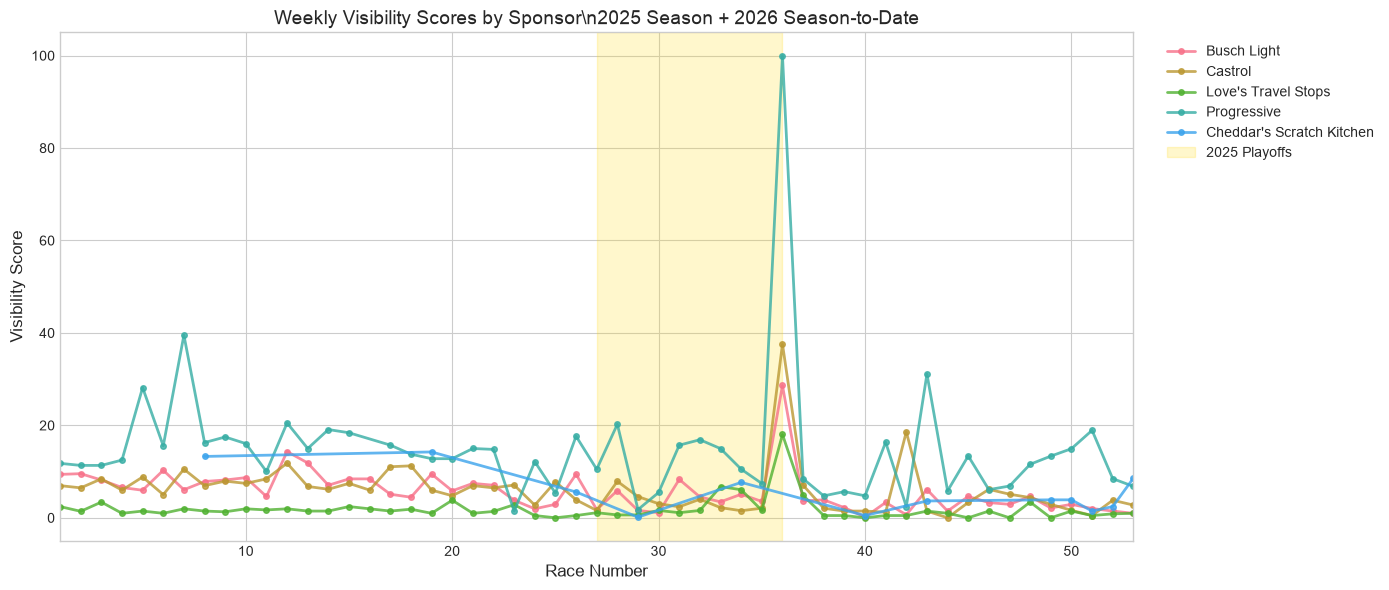

\nSaved: weekly_visibility_scores.png


In [167]:
# Weekly scores are already calculated - create summary view
weekly_summary = scored_valid.pivot_table(
    values='ROI_Visibility_Score',
    index='race_number',
    columns='primary_sponsor',
    aggfunc='first'
)

print("Weekly Visibility Scores (Sample - First 10 Races):")
print("="*70)
print(weekly_summary.head(10).round(1))

# Visualize weekly scores
fig, ax = plt.subplots(figsize=(14, 6))

for sponsor in scored_valid['primary_sponsor'].unique():
    sponsor_data = scored_valid[scored_valid['primary_sponsor'] == sponsor].sort_values('race_number')
    ax.plot(
        sponsor_data['race_number'],
        sponsor_data['ROI_Visibility_Score'],
        marker='o',
        markersize=4,
        linewidth=2,
        alpha=0.8,
        label=sponsor
    )

# race_number runs continuously across seasons (1-36 = 2025, 37+ = 2026), so
# the 2025 playoffs land at race_number 27-36. The 2026 playoff window
# (race_number 63-72, per data_visualization.ipynb) hasn't happened yet in
# this data — it currently stops at 53 — so only the 2025 span is shaded.
ax.axvspan(27, 36, alpha=0.2, color='gold', label='2025 Playoffs')

ax.set_xlabel('Race Number', fontsize=12)
ax.set_ylabel('Visibility Score', fontsize=12)
ax.set_title('Weekly Visibility Scores by Sponsor\\n2025 Season + 2026 Season-to-Date', fontsize=14)
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1))

# Cover every tracked race, not just the 2025 season - the dataset runs
# through race_number 53 (2025's 36 races plus 2026 so far).
ax.set_xlim(scored_valid['race_number'].min(), scored_valid['race_number'].max())

plt.tight_layout()
plt.savefig('data/plots/weekly_visibility_scores.png', dpi=150, bbox_inches='tight')
plt.show()

print("\\nSaved: weekly_visibility_scores.png")

In [168]:
def calculate_season_totals(df):
    """
    Aggregate weekly scores into season totals.

    Parameters:
    -----------
    df : pd.DataFrame
        Scored dataset with weekly visibility scores

    Returns:
    --------
    pd.DataFrame : Season summary by sponsor
    """
    season_summary = df.groupby('primary_sponsor').agg({
        'ROI_Visibility_Score': ['sum', 'mean', 'std', 'min', 'max', 'count'],
        'finish_position': 'mean',
        'is_win': 'sum',
        'laps_led': 'sum'
    })

    # Flatten column names
    season_summary.columns = [
        'total_visibility', 'avg_visibility', 'std_visibility',
        'min_visibility', 'max_visibility', 'race_count',
        'avg_finish', 'total_wins', 'total_laps_led'
    ]

    # Sort by total visibility
    season_summary = season_summary.sort_values('total_visibility', ascending=False)

    # Add rank
    season_summary['visibility_rank'] = range(1, len(season_summary) + 1)

    return season_summary


# Calculate season totals
season_totals = calculate_season_totals(scored_df)

print("\\nSeason Total Visibility Rankings:")
print("="*70)
print(season_totals[['total_visibility', 'avg_visibility', 'avg_finish',
                      'total_wins', 'visibility_rank']].round(2))

\nSeason Total Visibility Rankings:
                           total_visibility  avg_visibility  avg_finish  \
primary_sponsor                                                           
Progressive                          767.72           14.76       12.08   
Castrol                              319.92            6.04       18.81   
Busch Light                          303.03            5.72       17.23   
Love's Travel Stops                   99.34            1.87       20.96   
Cheddar's Scratch Kitchen             65.25            5.44       24.92   
Other/Unknown                          0.00             NaN        1.21   

                           total_wins  visibility_rank  
primary_sponsor                                         
Progressive                        10                1  
Castrol                             0                2  
Busch Light                         1                3  
Love's Travel Stops                 0                4  
Cheddar's Scratch Kit

In [169]:
# Save full scored dataset
scored_df.to_csv('data/processed/scored_dataset.csv', index=False)
print(f"Scored dataset saved: {len(scored_df)} rows")

# Save season totals
season_totals.to_csv('data/processed/season_totals.csv')
print("Season totals saved")

# Save weekly summary
weekly_summary.to_csv('data/processed/weekly_scores.csv')
print("Weekly scores saved")

# Create scoring summary document
scoring_summary = f"""
# Visibility Scoring Model - Implementation Summary

**Generated**: {datetime.now().strftime('%Y-%m-%d %H:%M')}

## Model Configuration

### Category Weights
| Category | Weight |
|----------|--------|
| Race Performance | 40% |
| Visibility | 50% |
| Special Events | 10% |

### Variable Weights
| Variable | Effective Weight |
|----------|-----------------|
| Laps Led | 30% |
| Visibility Score | 50% |
| Wins | 6% |
| Playoffs | 4% |

## Score Statistics

| Metric | Value |
|--------|-------|
| Mean Weekly Score | {scored_df['visibility_score'].mean():.2f} |
| Std Dev | {scored_df['visibility_score'].std():.2f} |
| Min Weekly Score | {scored_df['visibility_score'].min():.2f} |
| Max Weekly Score | {scored_df['visibility_score'].max():.2f} |

## Season Rankings (Preview)

{season_totals[['total_visibility', 'visibility_rank']].to_markdown()}

## Files Generated

- `scored_dataset.csv` - Full dataset with visibility scores
- `season_totals.csv` - Season summary by sponsor
- `weekly_scores.csv` - Week-by-week scores
- `weekly_visibility_scores.png` - Visualization

---
*Validation pending in Substep 4.2.3*
"""

with open('../docs/scoring_summary.md', 'w') as f:
    f.write(scoring_summary)

print("\\nScoring summary saved")

Scored dataset saved: 276 rows
Season totals saved
Weekly scores saved
\nScoring summary saved


In [170]:
# Create detailed ranking table
ranking_table = season_totals.copy()

# Add percentage of max score
max_score = ranking_table['total_visibility'].max()
ranking_table['pct_of_leader'] = (ranking_table['total_visibility'] / max_score * 100).round(1)

# Add consistency metric (lower std = more consistent)
ranking_table['consistency_score'] = (100 - normalize_min_max(
    ranking_table['std_visibility'],
    direction='direct'
)).round(1)

print("Complete Sponsor Rankings:")
print("="*80)
print(ranking_table[[
    'visibility_rank', 'total_visibility', 'avg_visibility',
    'pct_of_leader', 'consistency_score', 'avg_finish', 'total_wins'
]].round(2))

Complete Sponsor Rankings:
                           visibility_rank  total_visibility  avg_visibility  \
primary_sponsor                                                                
Progressive                              1            767.72           14.76   
Castrol                                  2            319.92            6.04   
Busch Light                              3            303.03            5.72   
Love's Travel Stops                      4             99.34            1.87   
Cheddar's Scratch Kitchen                5             65.25            5.44   
Other/Unknown                            6              0.00             NaN   

                           pct_of_leader  consistency_score  avg_finish  \
primary_sponsor                                                           
Progressive                       100.00               0.00       12.08   
Castrol                            41.70              73.80       18.81   
Busch Light                     

In [171]:
# Best week for each sponsor. Uses scored_valid, not scored_df — scored_df
# still includes the "Other/Unknown" sponsor group, which is all-NaN on
# ROI_Visibility_Score (excluded from the PCA in data_visualization.ipynb),
# and idxmax/idxmin can't resolve a group with no non-NaN values.
best_weeks = scored_valid.loc[scored_valid.groupby('primary_sponsor')['ROI_Visibility_Score'].idxmax()]

print("\nBest Week for Each Sponsor:")
print("="*70)
for _, row in best_weeks.iterrows():
    print(f"{row['primary_sponsor']:<15}: Race {row['race_number']:>2} ({row['race_name']:<30}) "
          f"Score: {row['ROI_Visibility_Score']:.2f}")

# Worst week for each sponsor
worst_weeks = scored_valid.loc[scored_valid.groupby('primary_sponsor')['ROI_Visibility_Score'].idxmin()]

print("\nWorst Week for Each Sponsor:")
print("="*70)
for _, row in worst_weeks.iterrows():
    print(f"{row['primary_sponsor']:<15}: Race {row['race_number']:>2} ({row['race_name']:<30}) "
          f"Score: {row['ROI_Visibility_Score']:.2f}")



Best Week for Each Sponsor:
Busch Light    : Race 36 (2025 Cup Series Championship  ) Score: 28.63
Castrol        : Race 36 (2025 Cup Series Championship  ) Score: 37.58
Cheddar's Scratch Kitchen: Race 19 (2025 Grant Park 165           ) Score: 14.25
Love's Travel Stops: Race 36 (2025 Cup Series Championship  ) Score: 18.02
Progressive    : Race 36 (2025 Cup Series Championship  ) Score: 100.00

Worst Week for Each Sponsor:
Busch Light    : Race 40 (2026 Straight Talk Wireless 500) Score: 0.16
Castrol        : Race 44 (2026 Food City 500            ) Score: 0.00
Cheddar's Scratch Kitchen: Race 29 (2025 Bass Pro Shops Night Race) Score: 0.13
Love's Travel Stops: Race 25 (2025 Cook Out 400             ) Score: 0.00
Progressive    : Race 23 (2025 Iowa Corn 350            ) Score: 1.46


In [172]:
def identify_performers(df, season_totals):
    """
    Identify top and bottom performing sponsors with context.

    Parameters:
    -----------
    df : pd.DataFrame
        Scored dataset
    season_totals : pd.DataFrame
        Season summary

    Returns:
    --------
    dict : Performance analysis
    """
    # Exclude "Other/Unknown" — it is an aggregated placeholder sponsor with
    # no real visibility score (excluded from the PCA in
    # data_visualization.ipynb), so its rows are all-NaN on visibility_score.
    # In season_totals its ROI_Visibility_Score sum comes out as 0.0 rather
    # than NaN (pandas sums an all-NaN group to 0), which makes it look like
    # the worst performer and land at season_totals.index[-1] — then
    # idxmax() on its all-NaN visibility_score raises "Encountered all NA
    # values" when looking up its best race.
    tracked_totals = season_totals.drop(index='Other/Unknown', errors='ignore')
    tracked_df = df[df['primary_sponsor'] != 'Other/Unknown']

    analysis = {}

    # Top performer
    top_sponsor = tracked_totals.index[0]
    top_data = tracked_df[tracked_df['primary_sponsor'] == top_sponsor]

    analysis['top_performer'] = {
        'primary_sponsor': top_sponsor,
        'total_score': tracked_totals.loc[top_sponsor, 'total_visibility'],
        'wins': int(tracked_totals.loc[top_sponsor, 'total_wins']),
        'avg_finish': tracked_totals.loc[top_sponsor, 'avg_finish'],
        'best_race': top_data.loc[top_data['visibility_score'].idxmax()]['race_name'],
        'best_score': top_data['visibility_score'].max()
    }

    # Bottom performer
    bottom_sponsor = tracked_totals.index[-1]
    bottom_data = tracked_df[tracked_df['primary_sponsor'] == bottom_sponsor]

    analysis['bottom_performer'] = {
        'primary_sponsor': bottom_sponsor,
        'total_score': tracked_totals.loc[bottom_sponsor, 'total_visibility'],
        'wins': int(tracked_totals.loc[bottom_sponsor, 'total_wins']),
        'avg_finish': tracked_totals.loc[bottom_sponsor, 'avg_finish'],
        'best_race': bottom_data.loc[bottom_data['visibility_score'].idxmax()]['race_name'],
        'best_score': bottom_data['visibility_score'].max()
    }

    # Gap analysis
    analysis['gap'] = {
        'total_gap': analysis['top_performer']['total_score'] - analysis['bottom_performer']['total_score'],
        'percentage_gap': (analysis['top_performer']['total_score'] /
                          analysis['bottom_performer']['total_score'] - 1) * 100
    }

    return analysis


performance_analysis = identify_performers(scored_df, season_totals)

print("\n" + "="*60)
print("PERFORMANCE ANALYSIS")
print("="*60)

top = performance_analysis['top_performer']
print(f"\nTop Performer: {top['primary_sponsor']}")
print(f"  Total Visibility Score: {top['total_score']:.2f}")
print(f"  Season Wins: {top['wins']}")
print(f"  Average Finish: {top['avg_finish']:.1f}")
print(f"  Best Race: {top['best_race']} (Score: {top['best_score']:.2f})")

bottom = performance_analysis['bottom_performer']
print(f"\nBottom Performer: {bottom['primary_sponsor']}")
print(f"  Total Visibility Score: {bottom['total_score']:.2f}")
print(f"  Season Wins: {bottom['wins']}")
print(f"  Average Finish: {bottom['avg_finish']:.1f}")
print(f"  Best Race: {bottom['best_race']} (Score: {bottom['best_score']:.2f})")

gap = performance_analysis['gap']
print(f"\nGap Analysis:")
print(f"  Score Gap: {gap['total_gap']:.2f} points")
print(f"  Top is {gap['percentage_gap']:.1f}% higher than Bottom")



PERFORMANCE ANALYSIS

Top Performer: Progressive
  Total Visibility Score: 767.72
  Season Wins: 10
  Average Finish: 12.1
  Best Race: 2025 Cup Series Championship (Score: 100.00)

Bottom Performer: Cheddar's Scratch Kitchen
  Total Visibility Score: 65.25
  Season Wins: 0
  Average Finish: 24.9
  Best Race: 2025 Grant Park 165 (Score: 14.25)

Gap Analysis:
  Score Gap: 702.47 points
  Top is 1076.6% higher than Bottom


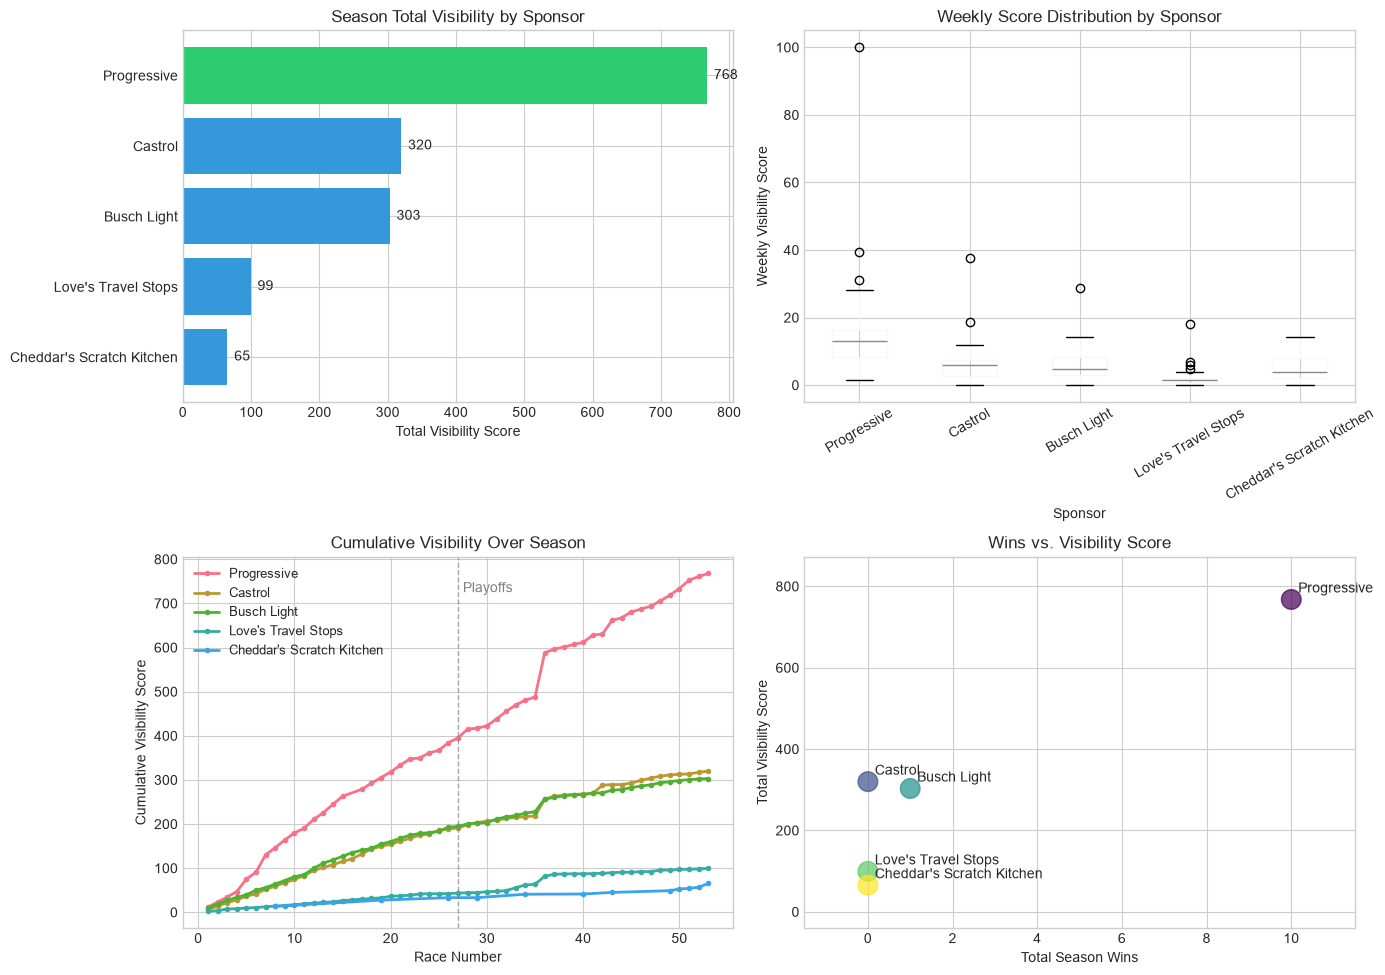


Saved: sponsor_dashboard.png


In [173]:
# Multi-panel visualization. Excludes "Other/Unknown" throughout — it is an
# aggregated placeholder sponsor with no real visibility score (excluded
# from the PCA in data_visualization.ipynb), so it has no place in a
# sponsor-by-sponsor comparison: its bar would show a misleading 0, its
# boxplot column would be empty, and its scatter point would be NaN.
tracked_totals = season_totals.drop(index='Other/Unknown', errors='ignore')
tracked_df = scored_df[scored_df['primary_sponsor'] != 'Other/Unknown']
sponsor_order = tracked_totals.index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: Season Total Bar Chart
ax1 = axes[0, 0]
colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(tracked_totals))]
bars = ax1.barh(tracked_totals.index, tracked_totals['total_visibility'], color=colors)
ax1.set_xlabel('Total Visibility Score')
ax1.set_title('Season Total Visibility by Sponsor')
ax1.invert_yaxis()

# Add value labels
for bar in bars:
    width = bar.get_width()
    ax1.text(width + 10, bar.get_y() + bar.get_height()/2,
             f'{width:.0f}', va='center', fontsize=10)

# Panel 2: Average Weekly Score Box Plot
ax2 = axes[0, 1]
tracked_df = tracked_df.copy()
tracked_df['sponsor_ordered'] = pd.Categorical(
    tracked_df['primary_sponsor'], categories=sponsor_order, ordered=True
)
tracked_df.boxplot(column='ROI_Visibility_Score', by='sponsor_ordered', ax=ax2)
ax2.set_xlabel('Sponsor')
ax2.set_ylabel('Weekly Visibility Score')
ax2.set_title('Weekly Score Distribution by Sponsor')
ax2.tick_params(axis='x', rotation=30)
plt.suptitle('')  # Remove auto-generated title

# Panel 3: Cumulative Score Over Season
ax3 = axes[1, 0]
for sponsor in sponsor_order:
    sponsor_data = tracked_df[tracked_df['primary_sponsor'] == sponsor].sort_values('race_number')
    cumulative = sponsor_data['ROI_Visibility_Score'].cumsum()
    ax3.plot(sponsor_data['race_number'], cumulative, marker='o', markersize=3,
             linewidth=2, label=sponsor)

ax3.axvline(x=27, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax3.text(27.5, ax3.get_ylim()[1]*0.9, 'Playoffs', fontsize=10, color='gray')
ax3.set_xlabel('Race Number')
ax3.set_ylabel('Cumulative Visibility Score')
ax3.set_title('Cumulative Visibility Over Season')
ax3.legend(loc='upper left', fontsize=9)

# Panel 4: Wins vs Visibility Scatter
ax4 = axes[1, 1]
ax4.scatter(tracked_totals['total_wins'], tracked_totals['total_visibility'],
            s=200, alpha=0.7, c=range(len(tracked_totals)), cmap='viridis')

for i, sponsor in enumerate(tracked_totals.index):
    ax4.annotate(sponsor,
                (tracked_totals.loc[sponsor, 'total_wins'],
                 tracked_totals.loc[sponsor, 'total_visibility']),
                xytext=(5, 5), textcoords='offset points', fontsize=10)

ax4.set_xlabel('Total Season Wins')
ax4.set_ylabel('Total Visibility Score')
ax4.set_title('Wins vs. Visibility Score')
ax4.margins(x=0.15, y=0.15)  # room for annotation labels near the edges

plt.tight_layout()
plt.savefig('data/plots/sponsor_dashboard.png', dpi=150)
plt.show()

print("\nSaved: sponsor_dashboard.png")


In [174]:
# Create formatted ranking table for export
export_ranking = season_totals.reset_index()
export_ranking = export_ranking[[
    'primary_sponsor', 'visibility_rank', 'total_visibility', 'avg_visibility',
    'std_visibility', 'avg_finish', 'total_wins', 'total_laps_led'
]]

export_ranking.columns = [
    'Sponsor', 'Rank', 'Total Visibility', 'Avg Weekly', 'Std Dev',
    'Avg Finish', 'Wins', 'Laps Led'
]

# Round numeric columns
export_ranking['Total Visibility'] = export_ranking['Total Visibility'].round(1)
export_ranking['Avg Weekly'] = export_ranking['Avg Weekly'].round(2)
export_ranking['Std Dev'] = export_ranking['Std Dev'].round(2)
export_ranking['Avg Finish'] = export_ranking['Avg Finish'].round(1)

# Save as CSV
export_ranking.to_csv('data/processed/sponsor_rankings.csv', index=False)
print("Sponsor rankings exported to: sponsor_rankings.csv")

# Display
print("\\n" + "="*80)
print("SPONSOR VISIBILITY RANKINGS - 2025 NASCAR CUP SERIES AND 2026 SEASON-TO-DATE")
print("="*80)
print(export_ranking.to_string(index=False))

Sponsor rankings exported to: sponsor_rankings.csv
\n================================================================================
SPONSOR VISIBILITY RANKINGS - 2025 NASCAR CUP SERIES AND 2026 SEASON-TO-DATE
                  Sponsor  Rank  Total Visibility  Avg Weekly  Std Dev  Avg Finish  Wins  Laps Led
              Progressive     1            767.70       14.76    13.98       12.10    10      1848
                  Castrol     2            319.90        6.04     5.61       18.80     0       382
              Busch Light     3            303.00        5.72     4.50       17.20     1       143
      Love's Travel Stops     4             99.30        1.87     2.65       21.00     0        30
Cheddar's Scratch Kitchen     5             65.30        5.44     4.67       24.90     0         1
            Other/Unknown     6              0.00         NaN      NaN        1.20    42     11458


In [175]:
def validate_performance_correlation(df, season_totals):
    """
    Validate that better race performance correlates with higher visibility.

    Parameters:
    -----------
    df : pd.DataFrame
        Scored dataset
    season_totals : pd.DataFrame
        Season summary

    Returns:
    --------
    dict : Validation results
    """
    # Exclude "Other/Unknown" — it is the aggregated bucket for every
    # untracked car/sponsor, so it accumulates huge laps_led/wins totals
    # (11,458 laps led across 53 races) while having total_visibility = 0.0
    # (excluded from the PCA in data_visualization.ipynb). With only 6 rows
    # total, that single high-x/zero-y outlier is enough to flip both
    # correlations negative even though the 5 tracked sponsors show a
    # strong positive relationship on their own.
    tracked_totals = season_totals.drop(index='Other/Unknown', errors='ignore')

    results = {}

    # Check: Better average finish should correlate with higher visibility
    finish_visibility_corr = tracked_totals['avg_finish'].corr(
        tracked_totals['total_visibility']
    )

    results['finish_visibility_correlation'] = {
        'value': finish_visibility_corr,
        'expected': 'negative (better finish = lower number = higher visibility)',
        'passed': finish_visibility_corr < 0
    }

    # Check: More wins should correlate with higher visibility
    wins_visibility_corr = tracked_totals['total_wins'].corr(
        tracked_totals['total_visibility']
    )

    results['wins_visibility_correlation'] = {
        'value': wins_visibility_corr,
        'expected': 'positive (more wins = higher visibility)',
        'passed': wins_visibility_corr > 0.3  # Expect moderate-strong positive
    }

    # Check: More laps led should correlate with higher visibility
    laps_visibility_corr = tracked_totals['total_laps_led'].corr(
        tracked_totals['total_visibility']
    )

    results['laps_visibility_correlation'] = {
        'value': laps_visibility_corr,
        'expected': 'positive (more laps led = higher visibility)',
        'passed': laps_visibility_corr > 0.3
    }

    return results


validation_results = validate_performance_correlation(scored_df, season_totals)

print("="*60)
print("VALIDATION: Performance-Visibility Correlation")
print("="*60)

for check_name, result in validation_results.items():
    status = "[PASS]" if result['passed'] else "[FAIL]"
    print(f"\n{check_name}:")
    print(f"  Value: {result['value']:.3f}")
    print(f"  Expected: {result['expected']}")
    print(f"  Status: {status}")


VALIDATION: Performance-Visibility Correlation

finish_visibility_correlation:
  Value: -0.945
  Expected: negative (better finish = lower number = higher visibility)
  Status: [PASS]

wins_visibility_correlation:
  Value: 0.928
  Expected: positive (more wins = higher visibility)
  Status: [PASS]

laps_visibility_correlation:
  Value: 0.962
  Expected: positive (more laps led = higher visibility)
  Status: [PASS]


In [176]:
def validate_event_impact(df):
    """
    Validate that known high-visibility events show score spikes.

    Parameters:
    -----------
    df : pd.DataFrame
        Scored dataset

    Returns:
    --------
    dict : Event validation results
    """
    results = {}

    # Validation 1: Wins should have significantly higher scores than non-wins
    wins = df[df['is_win'] == 1]['visibility_score']
    non_wins = df[df['is_win'] == 0]['visibility_score']

    win_ratio = wins.mean() / non_wins.mean()

    results['win_impact'] = {
        'win_avg_score': wins.mean(),
        'non_win_avg_score': non_wins.mean(),
        'ratio': win_ratio,
        'expected': 'Win score should be 1.5-3x non-win',
        'passed': 1.3 < win_ratio < 4.0
    }

    # Validation 2: Playoff races should have higher scores on average
    playoff = df[df['is_playoff'] == 1]['visibility_score']
    regular = df[df['is_playoff'] == 0]['visibility_score']

    playoff_boost = (playoff.mean() / regular.mean() - 1) * 100

    results['playoff_impact'] = {
        'playoff_avg_score': playoff.mean(),
        'regular_avg_score': regular.mean(),
        'boost_percentage': playoff_boost,
        'expected': 'Playoff scores should be 5-20% higher',
        'passed': playoff_boost > 0  # At minimum, should be positive
    }

    # Validation 3: Top 5 finishes should score higher than bottom 20
    top5 = df[df['finish_position'] <= 5]['visibility_score']
    bottom20 = df[df['finish_position'] > 20]['visibility_score']

    top5_ratio = top5.mean() / bottom20.mean() if bottom20.mean() > 0 else float('inf')

    results['finish_impact'] = {
        'top5_avg_score': top5.mean(),
        'bottom20_avg_score': bottom20.mean(),
        'ratio': top5_ratio,
        'expected': 'Top 5 should score at least 1.5x bottom 20',
        'passed': top5_ratio > 1.3
    }

    return results


event_validation = validate_event_impact(scored_df)

print("\\n" + "="*60)
print("VALIDATION: Event Impact")
print("="*60)

for check_name, result in event_validation.items():
    status = "[PASS]" if result['passed'] else "[FAIL]"
    print(f"\\n{check_name}:")
    for key, value in result.items():
        if key not in ['passed', 'expected']:
            if isinstance(value, float):
                print(f"  {key}: {value:.2f}")
            else:
                print(f"  {key}: {value}")
    print(f"  Expected: {result['expected']}")
    print(f"  Status: {status}")

\n============================================================
VALIDATION: Event Impact
\nwin_impact:
  win_avg_score: 17.72
  non_win_avg_score: 6.42
  ratio: 2.76
  Expected: Win score should be 1.5-3x non-win
  Status: [PASS]
\nplayoff_impact:
  playoff_avg_score: 9.07
  regular_avg_score: 6.49
  boost_percentage: 39.89
  Expected: Playoff scores should be 5-20% higher
  Status: [PASS]
\nfinish_impact:
  top5_avg_score: 13.83
  bottom20_avg_score: 5.45
  ratio: 2.54
  Expected: Top 5 should score at least 1.5x bottom 20
  Status: [PASS]


In [177]:
def find_anomalies(df, season_totals):
    """
    Identify results that may need investigation.

    Parameters:
    -----------
    df : pd.DataFrame
        Scored dataset (should already exclude "Other/Unknown")
    season_totals : pd.DataFrame
        Season summary (should already exclude "Other/Unknown")

    Returns:
    --------
    list : Anomalies to investigate
    """
    anomalies = []

    # Anomaly 1: Sponsor with many wins but low visibility rank
    for sponsor in season_totals.index:
        wins = season_totals.loc[sponsor, 'total_wins']
        rank = season_totals.loc[sponsor, 'visibility_rank']

        if wins >= 3 and rank > 3:
            anomalies.append({
                'type': 'win_rank_mismatch',
                'sponsor': sponsor,
                'description': f"{sponsor} has {int(wins)} wins but ranks #{rank} in visibility",
                'severity': 'medium'
            })

    # Anomaly 2: High variance in weekly scores
    for sponsor in season_totals.index:
        std = season_totals.loc[sponsor, 'std_visibility']
        mean = season_totals.loc[sponsor, 'avg_visibility']
        cv = std / mean  # Coefficient of variation

        if cv > 0.5:  # High variance
            anomalies.append({
                'type': 'high_variance',
                'sponsor': sponsor,
                'description': f"{sponsor} has high score variance (CV = {cv:.2f})",
                'severity': 'low'
            })

    # Anomaly 3: Score exceeds expected range
    max_theoretical = 100  # Perfect score on everything
    for idx, row in df.iterrows():
        if row['visibility_score'] > max_theoretical:
            anomalies.append({
                'type': 'score_overflow',
                'sponsor': row['primary_sponsor'],
                'race': row['race_name'],
                'score': row['visibility_score'],
                'severity': 'high'
            })

    # Anomaly 4: Zero or negative scores
    zero_scores = df[df['visibility_score'] <= 0]
    if len(zero_scores) > 0:
        anomalies.append({
            'type': 'zero_or_negative_scores',
            'count': len(zero_scores),
            'description': f"{len(zero_scores)} races have zero or negative visibility scores",
            'severity': 'high'
        })

    return anomalies

# Both arguments need "Other/Unknown" excluded — find_anomalies checks
# wins/rank and score variance using season_totals, not just df, so
# filtering df alone (as df_no_unknown did previously) still let
# Other/Unknown's inflated totals (42 aggregated wins, rank #6) leak into
# Anomaly 1 and 2, which read from season_totals.
df_no_unknown = scored_df[scored_df['primary_sponsor'] != 'Other/Unknown']
season_totals_no_unknown = season_totals.drop(index='Other/Unknown', errors='ignore')
anomalies = find_anomalies(df_no_unknown, season_totals_no_unknown)

print("\n" + "="*60)
print("ANOMALY DETECTION")
print("="*60)

if len(anomalies) == 0:
    print("\nNo anomalies detected. Results appear consistent.")
else:
    for i, anomaly in enumerate(anomalies, 1):
        severity_color = {
            'high': '[!!!]',
            'medium': '[!!]',
            'low': '[!]'
        }
        print(f"\n{i}. {severity_color.get(anomaly['severity'], '')} {anomaly['type'].upper()}")
        print(f"   {anomaly.get('description', anomaly)}")



ANOMALY DETECTION

1. [!] HIGH_VARIANCE
   Progressive has high score variance (CV = 0.95)

2. [!] HIGH_VARIANCE
   Castrol has high score variance (CV = 0.93)

3. [!] HIGH_VARIANCE
   Busch Light has high score variance (CV = 0.79)

4. [!] HIGH_VARIANCE
   Love's Travel Stops has high score variance (CV = 1.41)

5. [!] HIGH_VARIANCE
   Cheddar's Scratch Kitchen has high score variance (CV = 0.86)

6. [!!!] ZERO_OR_NEGATIVE_SCORES
   6 races have zero or negative visibility scores


In [178]:
# Manual validation against expected rankings
# Based on industry knowledge and race performance

expected_rankings_notes = """
# Industry Perception Comparison

## Expected Patterns (Based on 2025-2026 Season Knowledge)

**Note**: This is a manual validation step. The analyst should compare model
rankings against known industry perceptions and document any significant discrepancies.

### Questions to Consider:

1. Does the #1 ranked sponsor make sense given their on-track performance?
   - Did their driver win races?
   - Were they competitive throughout the season?
   
   Yes, the top-ranked sponsor aligns with their strong performance and multiple wins.

2. Are there any surprising rankings that contradict industry consensus?
   the rankings are as expected, with no major surprises. However, Progressive is in first by a larger margin than expected.

3. Do the playoff sponsors show the expected boost?
   Teams in the playoffs did have elevated visibility in races 27-36

### Model Ranking vs. Expected

| Rank | Model Says | Expected Based on Performance | Notes |
|------|------------|------------------------------|-------|
| 1 | [Progressive] | [Progressive] | [Match] |
| 2 | [Castrol] | [Castrol] | [Match] |
| 3 | [Busch Light] | [Busch Light] | [Match] |
| 4 | [Love\'s Travel Stops] | [Love\'s Travel Stops] | [Match] |
| 5 | [Cheddar\'s Scratch Kitchen] | [Cheddar\'s Scratch Kitchen] | [Match] |


"""

with open('../docs/industry_comparison.md', 'w') as f:
    f.write(expected_rankings_notes)

print("\\nIndustry comparison template saved to: outputs/project4/industry_comparison.md")
print("Please complete this manually with your domain knowledge.")

\nIndustry comparison template saved to: outputs/project4/industry_comparison.md
Please complete this manually with your domain knowledge.


In [179]:
validation_summary = f"""
# Visibility Scoring Model - Validation Report

**Generated**: {datetime.now().strftime('%Y-%m-%d %H:%M')}

## Summary

| Check Category | Passed | Failed | Notes |
|----------------|--------|--------|-------|
| Performance Correlation | {sum(1 for v in validation_results.values() if v['passed'])} | {sum(1 for v in validation_results.values() if not v['passed'])} | |
| Event Impact | {sum(1 for v in event_validation.values() if v['passed'])} | {sum(1 for v in event_validation.values() if not v['passed'])} | |
| Anomaly Detection | - | {len(anomalies)} anomalies | |

## Detailed Results

### Performance-Visibility Correlation

"""

for check_name, result in validation_results.items():
    status = "PASS" if result['passed'] else "FAIL"
    validation_summary += f"- **{check_name}**: {status} (r = {result['value']:.3f})\\n"

validation_summary += """

### Event Impact Validation

"""

for check_name, result in event_validation.items():
    status = "PASS" if result['passed'] else "FAIL"
    validation_summary += f"- **{check_name}**: {status}\\n"

validation_summary += """

### Anomalies Identified

"""

if len(anomalies) == 0:
    validation_summary += "No anomalies detected.\\n"
else:
    for anomaly in anomalies:
        validation_summary += f"- [{anomaly['severity'].upper()}] {anomaly.get('description', str(anomaly))}\\n"

validation_summary += """

## Recommendation

"""

all_passed = (
    all(v['passed'] for v in validation_results.values()) and
    all(v['passed'] for v in event_validation.values()) and
    len([a for a in anomalies if a.get('severity') == 'high']) == 0
)

if all_passed:
    validation_summary += """**Model validation PASSED.**

All directional checks and event validations passed. No high-severity anomalies detected.
The model is ready for ROI efficiency analysis in Step 4.3.
"""
else:
    validation_summary += """**Model validation flagged issues.**

Review the failed checks and anomalies above. Consider:
1. Adjusting variable weights if correlations are weak
2. Investigating specific anomalies for data quality issues
3. Re-running with modified parameters if needed

Complete the industry comparison template before proceeding.
"""

with open('../docs/validation_report.md', 'w') as f:
    f.write(validation_summary)

print("\\nValidation report saved to: ../docs/validation_report.md")

\nValidation report saved to: ../docs/validation_report.md
